# Corn (Maize) Disease Classification

In [9]:
import pathlib
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np

BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS   = 3
EPOCHS     = 50
# Find the Crop-Care-AI project root regardless of where the kernel's CWD is.
# The project root always contains both "training/" and "api/" subdirectories.
_cwd = pathlib.Path().resolve()
_project_root = None
for _p in [_cwd] + list(_cwd.parents):
    if (_p / "training").is_dir() and (_p / "api").is_dir():
        _project_root = _p
        break
if _project_root is None:
    raise RuntimeError(f"Could not locate project root from CWD: {_cwd}")

DATA_DIR = str(_project_root.parent / "Data" / "Corn (Maize)")
print(f"Project root : {_project_root}")
print(f"DATA_DIR     : {DATA_DIR}")

Project root : D:\Development\Shravani\Crop-Care-AI
DATA_DIR     : D:\Development\Shravani\Data\Corn (Maize)


In [10]:
# Load pre-split datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR + "/Train", seed=123, shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE), batch_size=BATCH_SIZE)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR + "/Val", seed=123, shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE), batch_size=BATCH_SIZE)
test_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR + "/Test", seed=123, shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE), batch_size=BATCH_SIZE)

class_names = train_ds.class_names
print("Classes:", class_names)
print(f"Train batches: {len(train_ds)}  |  Val: {len(val_ds)}  |  Test: {len(test_ds)}")

Found 7316 files belonging to 4 classes.
Found 1645 files belonging to 4 classes.
Found 188 files belonging to 4 classes.
Classes: ['Cercospora Leaf Spot', 'Common Rust', 'Healthy', 'Northern Leaf Blight']
Train batches: 229  |  Val: 52  |  Test: 6


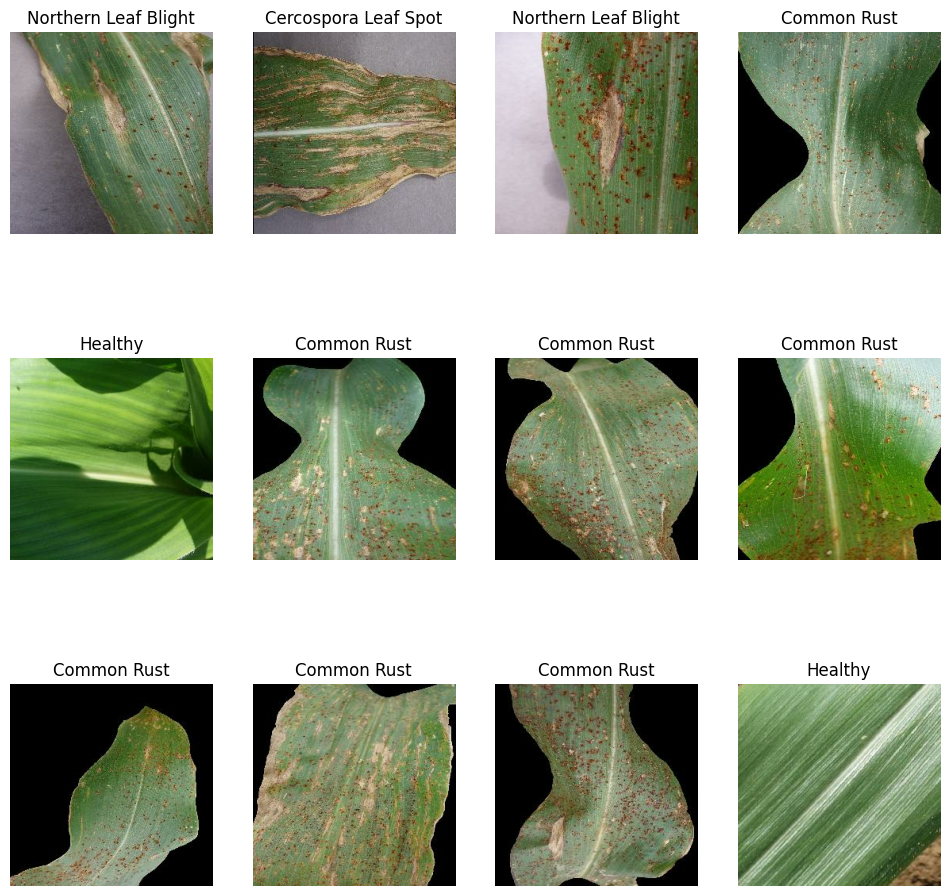

In [11]:
# Visualize sample images
plt.figure(figsize=(12, 12))
for image_batch, labels_batch in train_ds.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")

Project root : D:\Development\Shravani\Crop-Care-AI
DATA_DIR     : D:\Development\Shravani\Data\Corn (Maize)
Found 7316 files belonging to 4 classes.
Found 1645 files belonging to 4 classes.
Found 188 files belonging to 4 classes.
Classes (4): ['Cercospora Leaf Spot', 'Common Rust', 'Healthy', 'Northern Leaf Blight']


C:\Users\Rohit Chaskar\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
229/229 ━━━━━━━━━━━━━━━━━━━━ 302s 1s/step - accuracy: 0.5067 - loss: 0.9405 - val_accuracy: 0.5666 - val_loss: 0.7503
Epoch 2/30
229/229 ━━━━━━━━━━━━━━━━━━━━ 299s 1s/step - accuracy: 0.6151 - loss: 0.7594 - val_accuracy: 0.7258 - val_loss: 0.6792
Epoch 3/30
229/229 ━━━━━━━━━━━━━━━━━━━━ 298s 1s/step - accuracy: 0.7924 - loss: 0.4394 - val_accuracy: 0.8796 - val_loss: 0.2848
Epoch 4/30
229/229 ━━━━━━━━━━━━━━━━━━━━ 301s 1s/step - accuracy: 0.9047 - loss: 0.2203 - val_accuracy: 0.8827 - val_loss: 0.2724
Epoch 5/30
229/229 ━━━━━━━━━━━━━━━━━━━━ 293s 1s/step - accuracy: 0.9295 - loss: 0.1750 - val_accuracy: 0.8985 - val_loss: 0.2727
Epoch 6/30
229/229 ━━━━━━━━━━━━━━━━━━━━ 296s 1s/step - accuracy: 0.9404 - loss: 0.1508 - val_accuracy: 0.8650 - val_loss: 0.3455
Epoch 7/30
229/229 ━━━━━━━━━━━━━━━━━━━━ 296s 1s/step - accuracy: 0.9423 - loss: 0.1442 - val_accuracy: 0.8796 - val_loss: 0.4814
Epoch 8/30
229/229 ━━━━━━━━━━━━━━━━━━━━ 300s 1s/step - accuracy: 0.9505 - loss: 0.1247 - val_accu

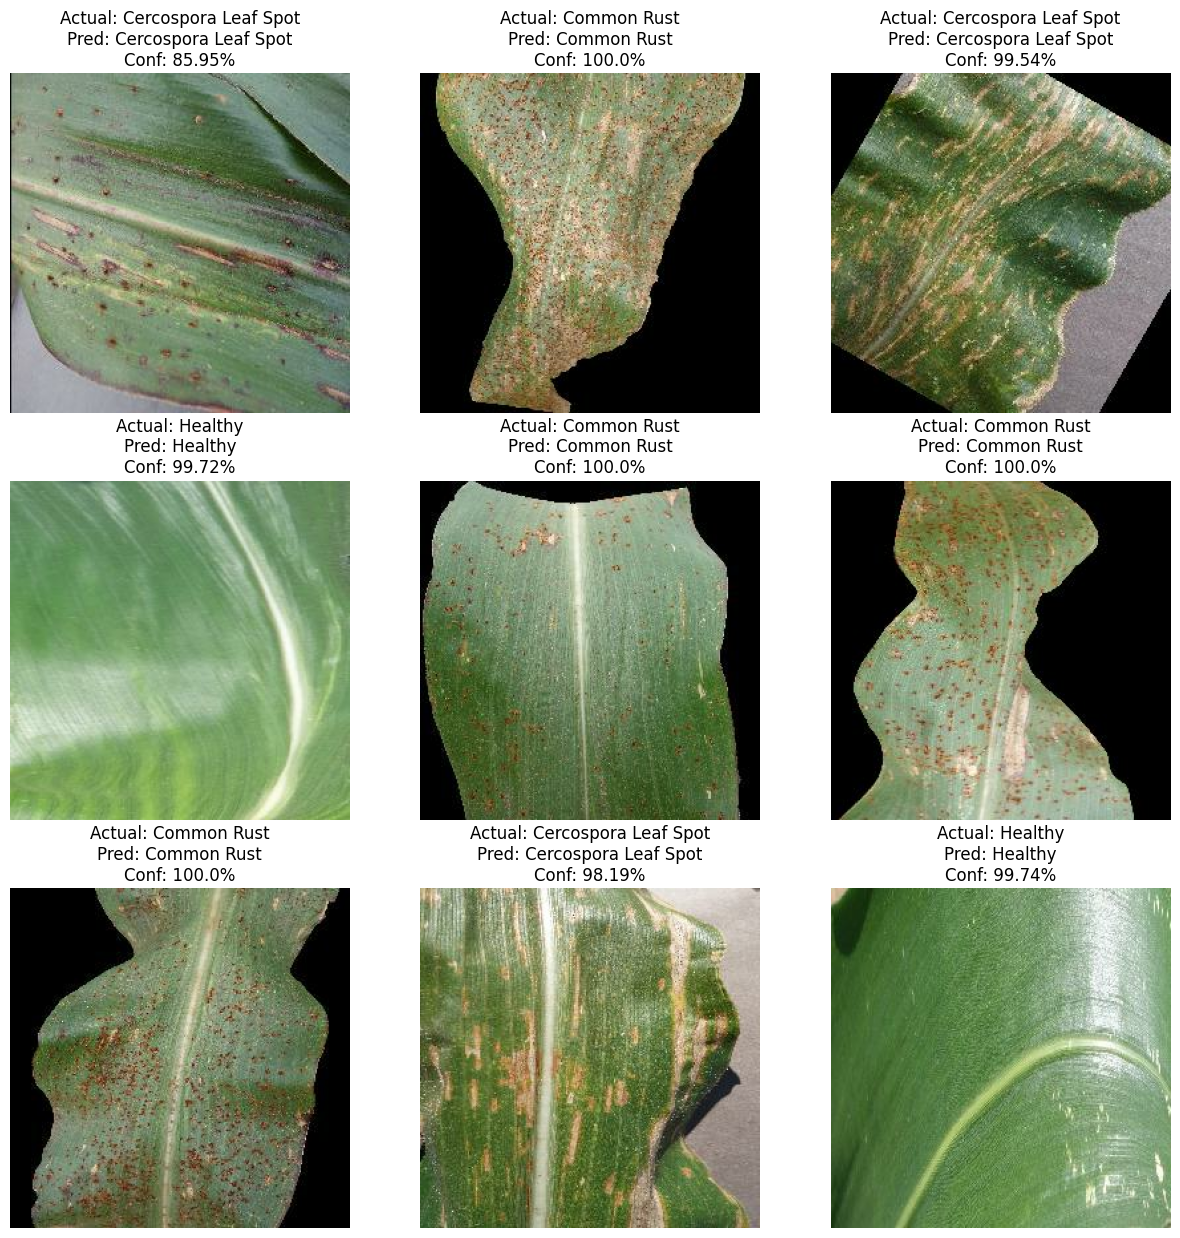

In [12]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np
import pathlib

# ---------- locate project root ----------
_cwd = pathlib.Path().resolve()
_project_root = None
for _p in [_cwd] + list(_cwd.parents):
    if (_p / "training").is_dir() and (_p / "api").is_dir():
        _project_root = _p
        break
if _project_root is None:
    raise RuntimeError(f"Could not locate project root from CWD: {_cwd}")

DATA_DIR = str(_project_root.parent / "Data" / "Corn (Maize)")
print(f"Project root : {_project_root}")
print(f"DATA_DIR     : {DATA_DIR}")

BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS = 3
EPOCHS = 30

# ---------- load data ----------
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR + "/Train", seed=123, shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE), batch_size=BATCH_SIZE)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR + "/Val", seed=123, shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE), batch_size=BATCH_SIZE)
test_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR + "/Test", seed=123, shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE), batch_size=BATCH_SIZE)

class_names = train_ds.class_names
n_classes = len(class_names)
print(f"Classes ({n_classes}): {class_names}")

train_ds = train_ds.cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)

# ---------- preprocessing & augmentation ----------
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1./255),
])
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y)).prefetch(tf.data.AUTOTUNE)

# ---------- model ----------
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
model = models.Sequential([
    resize_and_rescale,
    layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])
model.build(input_shape=input_shape)
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])
history = model.fit(train_ds, batch_size=BATCH_SIZE, validation_data=val_ds, verbose=1, epochs=EPOCHS)
scores = model.evaluate(test_ds)
print("Test loss, Test accuracy:", scores)

# ---------- inference ----------
def predict(model, img):
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)
    predictions = model.predict(img_array)
    return class_names[np.argmax(predictions[0])], round(100 * np.max(predictions[0]), 2)

plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        pred_class, confidence = predict(model, images[i].numpy())
        plt.title(f"Actual: {class_names[labels[i]]}\nPred: {pred_class}\nConf: {confidence}%")
        plt.axis("off")

# Save
import os
os.makedirs("../saved_models", exist_ok=True)
existing = os.listdir("../saved_models")
versions = [int(v.replace('.keras', '')) for v in existing if v.replace('.keras', '').isdigit()]
model_version = max(versions + [0]) + 1
model.save(f"../saved_models/{model_version}.keras")
model.save("../corn.keras")
print(f"Saved: ../saved_models/{model_version}.keras  and  ../corn.keras")